# Week 9 - Introduction to Neural Networks

**Siqi Wang s2823896, Wenhui Yu s2803003, Yichen Zhang s2804697**

### Aims

The main concepts covered in this notebook are: 

>* getting familiar with the basics of keras
>* input-output with keras
>* construction of neural network models with keras

This week, we will be exploring the basics of keras and building and fitting our first neural network with keras. For a quick introduction, please see https://keras.io/getting_started/intro_to_keras_for_engineers/

When completing worksheets:

>- You will have tasks tagged by (CORE) and (EXTRA). 
>- Your primary aim is to complete the (CORE) components during the WS session, afterwards you can try to complete the (EXTRA) tasks for your self-learning process. 

Instructions for submitting your workshops can be found at the end of worksheet. As a reminder, you must submit a pdf of your notebook on Learn by 16:00 PM on the Friday of the week the workshop was given.

# Setup <a id='setup'></a>

## Packages

Let's load the some of the packages needed for this workshop. 

In [1]:
# Import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

# Part 1: Simulated Data

In the first part of this workshop, we will work with a simple simulated example to gain some basic understanding of neural networks and keras.

We generate $N=2000$ simulated data points. First we generate the labels assuming that:
$$  y_i \sim \text{Bern}(0.5).$$
Next, we generate the features of dimension $D=2$. The first feature is simulated uniformly in $[-\pi,\pi]$
$$x_{i,1} \sim \text{Uniform}(-\pi,\pi).$$
For the second feature, if $y=0$, then
$$x_{i,2} \sim \text{Norm}(\cos( x_{i,1}),\sigma^2).$$
Otherwise, if $y=1$, then
$$x_{i,2} \sim  \text{Norm}(1+ \cos( x_{i,1}),\sigma^2).$$

In [2]:
# Generate data
keras.utils.set_random_seed(11205)
N = 2000
D = 2
y = np.random.binomial(1, 0.5, N)
X = np.zeros((N, D))
X[:,0] = np.random.uniform(-np.pi, np.pi, N)
X[y == 0,1] = np.cos(X[y == 0,0]) + np.random.normal(0, 0.25, (y == 0).sum())
X[y == 1,1] = 1 + np.cos(X[y == 1,0]) + np.random.normal(0, 0.25, (y == 1).sum())

### 🚩 Exercise 1 (CORE)

Plot the data colored by the class labels. 

**EXTRA.** Derive the true decision boundary and add it to the plot. 

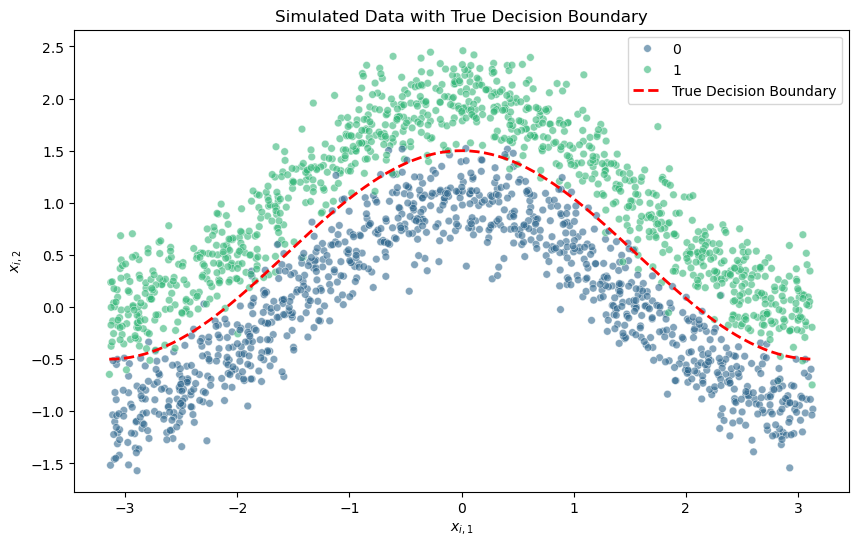

In [5]:
# Code for your answer here!
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="viridis", alpha=0.6, s=30)

# EXTRA: Add the true decision boundary
x1_boundary = np.linspace(-np.pi, np.pi, 200)
x2_boundary = 0.5 + np.cos(x1_boundary)

plt.plot(x1_boundary, x2_boundary, color='red', linewidth=2, linestyle='--', label='True Decision Boundary')
plt.xlabel('$x_{i,1}$')
plt.ylabel('$x_{i,2}$')
plt.title('Simulated Data with True Decision Boundary')
plt.legend()
plt.show()

**EXTRA.** Type your answer here\
The true decision boundary (the Bayes optimal decision boundary) is the set of points in the feature space where the posterior probabilities of both classes are exactly equal:$$P(y=1 \mid \mathbf{x}) = P(y=0 \mid \mathbf{x})$$Given that the classes are generated with equal probability from a Bernoulli(0.5) distribution, the prior probabilities are equal: $P(y=1) = P(y=0) = 0.5$. By Bayes' theorem, the boundary simplifies to where the likelihood functions are equal:$$p(\mathbf{x} \mid y=1) = p(\mathbf{x} \mid y=0)$$We know that the first feature, $x_{i,1}$, is drawn from $\text{Uniform}(-\pi, \pi)$ independent of the class $y$. Therefore, we can divide both sides by $p(x_{i,1})$ and focus strictly on the conditional probability of $x_{i,2}$:$$p(x_{i,2} \mid x_{i,1}, y=1) = p(x_{i,2} \mid x_{i,1}, y=0)$$Next, substitute the Probability Density Functions (PDFs) of the Normal distributions provided in the problem setup. Both distributions share the same variance ($\sigma^2$), so the normalization constant $\frac{1}{\sqrt{2\pi\sigma^2}}$ is identical for both and can be ignored.Equating the exponent arguments:$$\exp\left(-\frac{(x_2 - \cos(x_1))^2}{2\sigma^2}\right) = \exp\left(-\frac{(x_2 - (1 + \cos(x_1)))^2}{2\sigma^2}\right)$$Take the natural logarithm of both sides and multiply by $-2\sigma^2$:$$(x_2 - \cos(x_1))^2 = (x_2 - (1 + \cos(x_1)))^2$$Expand both squared terms:$$x_2^2 - 2x_2\cos(x_1) + \cos^2(x_1) = x_2^2 - 2x_2(1 + \cos(x_1)) + (1 + \cos(x_1))^2$$Expand the right side further:$$x_2^2 - 2x_2\cos(x_1) + \cos^2(x_1) = x_2^2 - 2x_2 - 2x_2\cos(x_1) + 1 + 2\cos(x_1) + \cos^2(x_1)$$Cancel the common terms ($x_2^2$, $-2x_2\cos(x_1)$, and $\cos^2(x_1)$) from both sides:$$0 = -2x_2 + 1 + 2\cos(x_1)$$Finally, rearrange to solve for $x_2$ to get the equation of the boundary curve: $$2x_2 = 1 + 2\cos(x_1)$$ $$x_2 = 0.5 + \cos(x_1)$$ This equation defines the true decision boundary separating the two classes in the feature space.

## Building a baseline logistic regression in keras

Let's start by building a logistic regression model in keras, using the `Functional` model: https://keras.io/guides/functional_api/ 

A `Functional` model provides a way to build a directed graph of `Layers` that connect to each other. `Layers` are the basic building blocks of neural networks in keras:  https://keras.io/api/layers/

To construct a logistic regression model, we only need two layers: 
- an input layer, which we construct using an `Input` layer: https://keras.io/api/layers/core_layers/input/ 
- an output layer, which we construct using a `Dense` layer: https://keras.io/api/layers/core_layers/dense/

In [6]:
# Defining the layers of the model
input_layer = keras.layers.Input(shape=(D,))
logit_layer = keras.layers.Dense(1, activation='sigmoid')

Then, we combine the layers and create our model which connects the input and output. 

In [7]:
output = logit_layer(input_layer)
model_lr = keras.models.Model(input_layer, output)
model_lr.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Print the number of layers in the model
print(len(model_lr.layers)) 

2


Alternatively, we can build the model using the `Sequential` model, see https://keras.io/api/models/sequential/ and https://keras.io/guides/sequential_model/. A `Sequential` model is esssentially a plain stack of `Layers` where each layer has exactly one input tensor and one output tensor, while a `Functional` model allows more general constructions (i.e. a graph of layers). 

In [9]:
model_lr2 = keras.Sequential(
    [
        keras.Input(shape=(D,)),
        keras.layers.Dense(1, activation='sigmoid'),
    ]
)
model_lr2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Now, we are ready to compile the model: https://keras.io/api/models/model_training_apis/

When compiling, we need to specify:
- a loss function: https://keras.io/api/losses/
- an optimizer: https://keras.io/api/optimizers/
- (optionally) metrics: https://keras.io/api/metrics/

In [10]:
model_lr.compile(
    loss='binary_crossentropy', # or loss=keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam', # or  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
       keras.metrics.BinaryAccuracy(name='accuracy'),
       keras.metrics.AUC(name='auc')
    ],
)

### Training the model

Now, we are ready to to fit the model! We need to specifiy: 
- the number of `epochs` (which is the number of times that we cycle through the whole training data during gradient descent), 

and optionally various other parameters, such as 

- `shuffle` (e.g. `shuffle=True`), which specifies whether to shuffle the training data before each epoch.
- `validation_split` which is a float between 0 and 1, determining the fraction of the training data to be used as validation data. The model will set apart this fraction of the training data, will not train on it, and will evaluate the loss and any model metrics on this data at the end of each epoch. This is useful for **early stopping**, i.e. determining if training should be stopped early to prevent overfitting.
- `batch_size`: Integer or None. Number of samples per gradient update. If unspecified, batch_size will default to 32. 
For more details, see: https://keras.io/api/models/model_training_apis/

**Caution:** the data is not shuffled before splitting the data into a validation set. If the data are ordered in particular way when stored, then the training and validation sets can potentially characterize different populations. Thus, it is recommend to first shuffle the order of your data before fitting.  

In [ ]:
# If you need to shuffle the data before fitting uncomment the following lines
# from sklearn.utils import shuffle
# X, y = shuffle(X, y, random_state=11205)

In [11]:
model_lr.fit(x=X, y=y, epochs=50, shuffle=True, validation_split=0.1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5272 - auc: 0.5536 - loss: 0.8589 - val_accuracy: 0.5250 - val_auc: 0.5678 - val_loss: 0.8517
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5344 - auc: 0.5721 - loss: 0.8220 - val_accuracy: 0.5350 - val_auc: 0.5887 - val_loss: 0.8177
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5389 - auc: 0.5955 - loss: 0.7877 - val_accuracy: 0.5300 - val_auc: 0.6126 - val_loss: 0.7864
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5411 - auc: 0.6241 - loss: 0.7562 - val_accuracy: 0.5300 - val_auc: 0.6355 - val_loss: 0.7576
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5472 - auc: 0.6561 - loss: 0.7275 - val_accuracy: 0.5250 - val_auc: 0.6572 - val_loss: 0.7315
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5483 - auc: 0.6863 - loss: 0.7014 - val_accuracy: 0.5150 - val_auc: 0.6845 - val_loss: 0.7080
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

Let's plot the metrics as a function of the number of epochs.

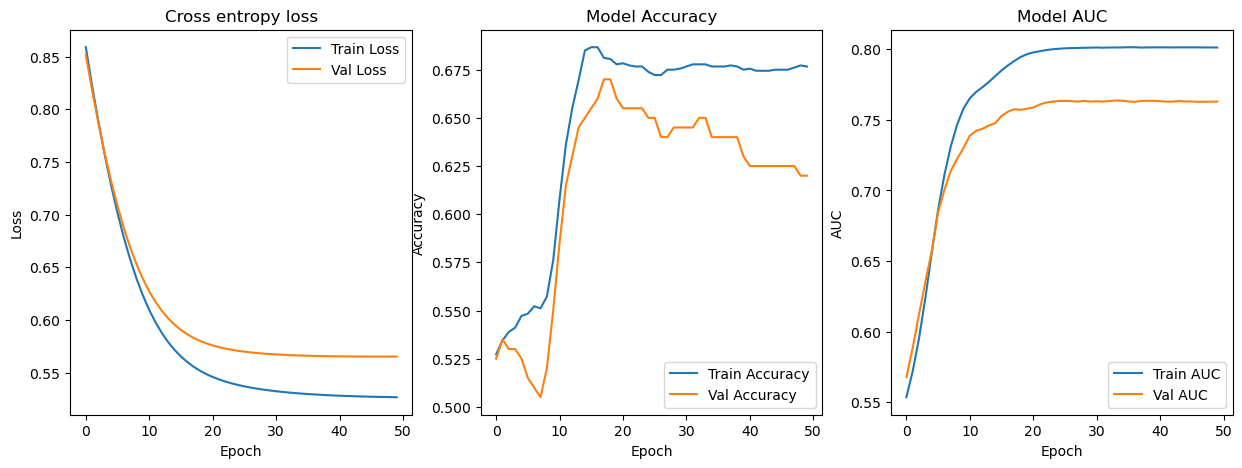

In [12]:
# Plot the training history
history = model_lr.history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(history['loss'], label='Train Loss')
ax[0].plot(history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[1].plot(history['accuracy'], label='Train Accuracy')
ax[1].plot(history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[2].plot(history['auc'], label='Train AUC')
ax[2].plot(history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()
plt.show()

If you notice that the validation loss (and metrics) is still decreasing (increasing) as a function of epochs, this suggests that you may need to train the model longer.

If you notice that the validation loss (and metrics) starts to increase (decrease) as a function of epochs, this suggests that the model is starting to overfit. Based on this, we can determine the number of epochs to use based on the U-shape of the validation loss (this is known as early stopping, for more info see: https://keras.io/api/callbacks/early_stopping/). 

### Testing the model

Now, we can use `.predict()` to make predictions. Let's predict at a grid of test points and draw a heatmap of the predicted probabilities.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step


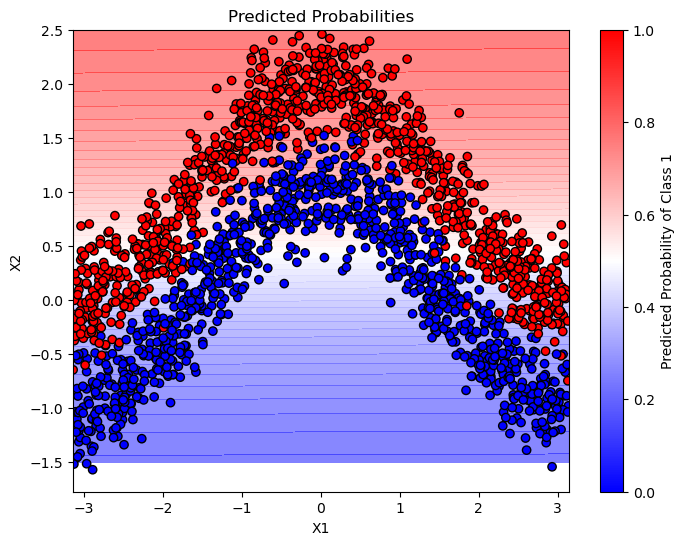

In [13]:
# Create a grid of test points
X_grid1, X_grid2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-1.5, 2.5, 100))
X_grid = np.column_stack([X_grid1.ravel(), X_grid2.ravel()])

# Predict probabilities 
y_pred_prob_lr = model_lr.predict(X_grid)

# Draw a heatmap of the predicted probabilities
plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_lr.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

### 🚩 Exercise 2 (CORE)

- Generate 1000 test data points from the same data generating process used to generated the training data.
- Compute the `classification_report` and `confusion_matrix`
- Is the result what you expect, and why?

In [14]:
# Code for your answer here!
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

N_test = 1000
D = 2
y_test = np.random.binomial(1, 0.5, N_test)

X_test = np.zeros((N_test, D))
X_test[:, 0] = np.random.uniform(-np.pi, np.pi, N_test)

X_test[y_test == 0, 1] = np.cos(X_test[y_test == 0, 0]) + np.random.normal(0, 0.25, (y_test == 0).sum())
X_test[y_test == 1, 1] = 1 + np.cos(X_test[y_test == 1, 0]) + np.random.normal(0, 0.25, (y_test == 1).sum())

y_pred_prob = model_lr.predict(X_test)
y_pred_class = (y_pred_prob > 0.5).astype("int32")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
Confusion Matrix:
[[332 164]
 [153 351]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.67      0.68       496
           1       0.68      0.70      0.69       504

    accuracy                           0.68      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.68      0.68      0.68      1000



_Yes, this result is exactly what we should expect.\
The baseline model we built (model_lr) is a simple logistic regression model, meaning it consists of just an input layer directly connected to a single output node with a sigmoid activation. By definition, a standard logistic regression model is only capable of learning a linear decision boundary (a straight line).\
However, as we established in Part 1, the true decision boundary separating our simulated classes is highly non-linear (it follows a cosine curve). Because the model is trying to draw a straight line through curved, overlapping data, it severely underfits the data. This fundamental mismatch between the model's capacity and the data's complexity explains the relatively low accuracy of 68% and the high number of errors in the confusion matrix._

### Adding a hidden layer

Now, let's add a hidden layer, with 2 neurons.

In [15]:
input_layer = keras.Input(shape=(D,))
hidden_layer = keras.layers.Dense(2, activation='relu')(input_layer)
output_layer = keras.layers.Dense(1, activation='sigmoid')(hidden_layer)
model_hidden2 = keras.Model(inputs=input_layer, outputs=output_layer)
model_hidden2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

### 🚩 Exercise 3 (CORE)

Compile the model, train and plot the metrics as a function of epochs. 

Continue to train the model for more epochs as needed. Note: rerun the fit line will continue to train the model from where it left off.

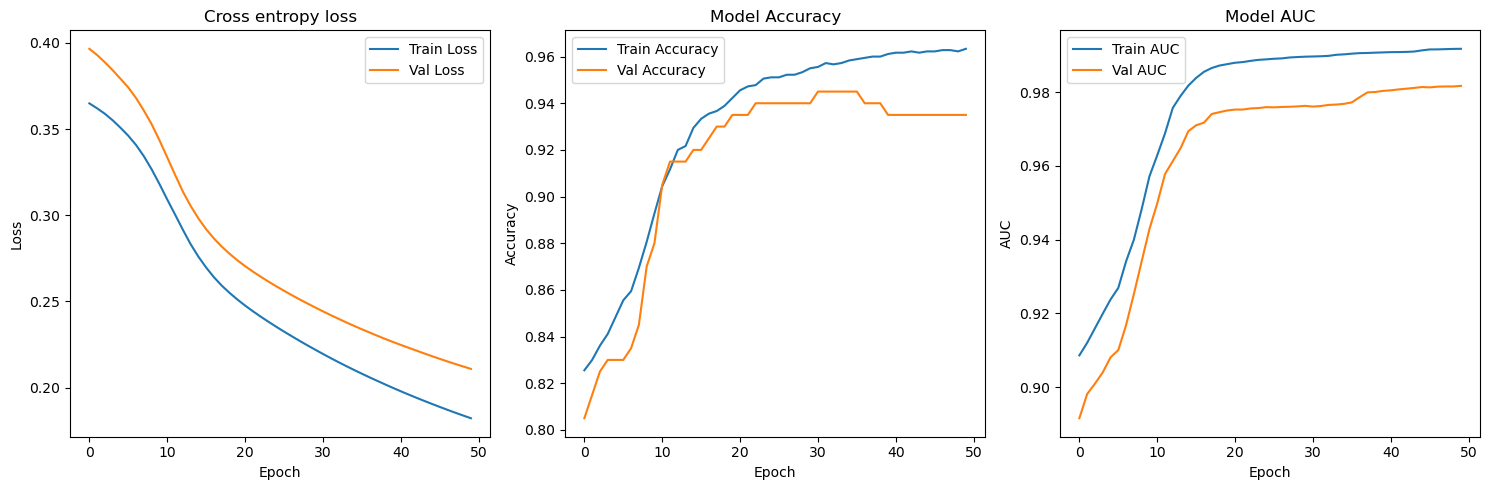

In [19]:
# Code for your answer here!
model_hidden2.compile(
    loss='binary_crossentropy', 
    optimizer='adam',
    metrics=[
        keras.metrics.BinaryAccuracy(name='accuracy'),
        keras.metrics.AUC(name='auc')
    ]
)

# Train the model
history_hidden2 = model_hidden2.fit(
    x=X, 
    y=y, 
    epochs=50, 
    shuffle=True, 
    validation_split=0.1,
    verbose=0
)

# Plot the metrics
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot Loss
ax[0].plot(history_hidden2.history['loss'], label='Train Loss')
ax[0].plot(history_hidden2.history['val_loss'], label='Val Loss')
ax[0].set_title('Cross entropy loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Plot Accuracy
ax[1].plot(history_hidden2.history['accuracy'], label='Train Accuracy')
ax[1].plot(history_hidden2.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

# Plot AUC
ax[2].plot(history_hidden2.history['auc'], label='Train AUC')
ax[2].plot(history_hidden2.history['val_auc'], label='Val AUC')
ax[2].set_title('Model AUC')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('AUC')
ax[2].legend()

plt.tight_layout()
plt.show()

### 🚩 Exercise 4 (CORE)

Draw a heatmap of the predicted probabilities. How does the model perform now?

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step


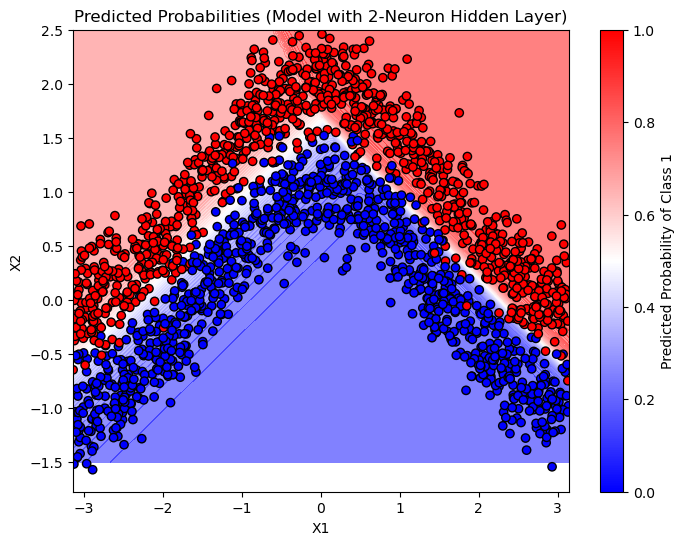

In [20]:
# Code for your answer here!
import numpy as np
import matplotlib.pyplot as plt

X_grid1, X_grid2 = np.meshgrid(np.linspace(-np.pi, np.pi, 100), np.linspace(-1.5, 2.5, 100))
X_grid = np.column_stack([X_grid1.ravel(), X_grid2.ravel()])

y_pred_prob_hidden2 = model_hidden2.predict(X_grid)

plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_hidden2.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted Probabilities (Model with 2-Neuron Hidden Layer)')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

_The model performs significantly better than the baseline logistic regression model. It is now able to capture the non-linear relationship in the data.\
Looking at the heatmap, the decision boundary is no longer a single straight line. Instead, it has formed a distinct "V" or "tent" shape.\
This happens because we introduced a hidden layer with exactly two neurons using a non-linear activation function (ReLU). Each neuron essentially learns a single linear boundary, and the network combines them to form a piecewise linear approximation of the true boundary.\
While this two-piece boundary is a much better fit for our underlying cosine curve than the flat line from the previous model, it is still a bit rigid. If we were to increase the number of neurons in this hidden layer, the model would have more "pieces" to work with, allowing it to bend more smoothly and approximate the true curved boundary even more closely._

### Visualizing the output of each neuron

By visualizing the output of each neuron, we can gain an understanding of the features extracted. 

In the code below, we create a keras model for the mapping of the inputs to the hidden layer and pass through the data. By plotting the output of the hidden layer, we observe that:
- the first hidden feature captures the separation of the two classes when $x_1<0$ and 
- the second hidden feature captures the separation of the two classes when $x_1>0$.

In [21]:
# Extract the output of the hidden layer
hidden_layer_model = keras.Model(inputs=model_hidden2.input, outputs=model_hidden2.layers[1].output)

# Hidden output for the observed data
z =hidden_layer_model(X)
# Convert to numpy array
z = z.numpy()

# Hidden output for the test points
z_grid =hidden_layer_model(X_grid)
# Convert to numpy array
z_grid = z_grid.numpy()

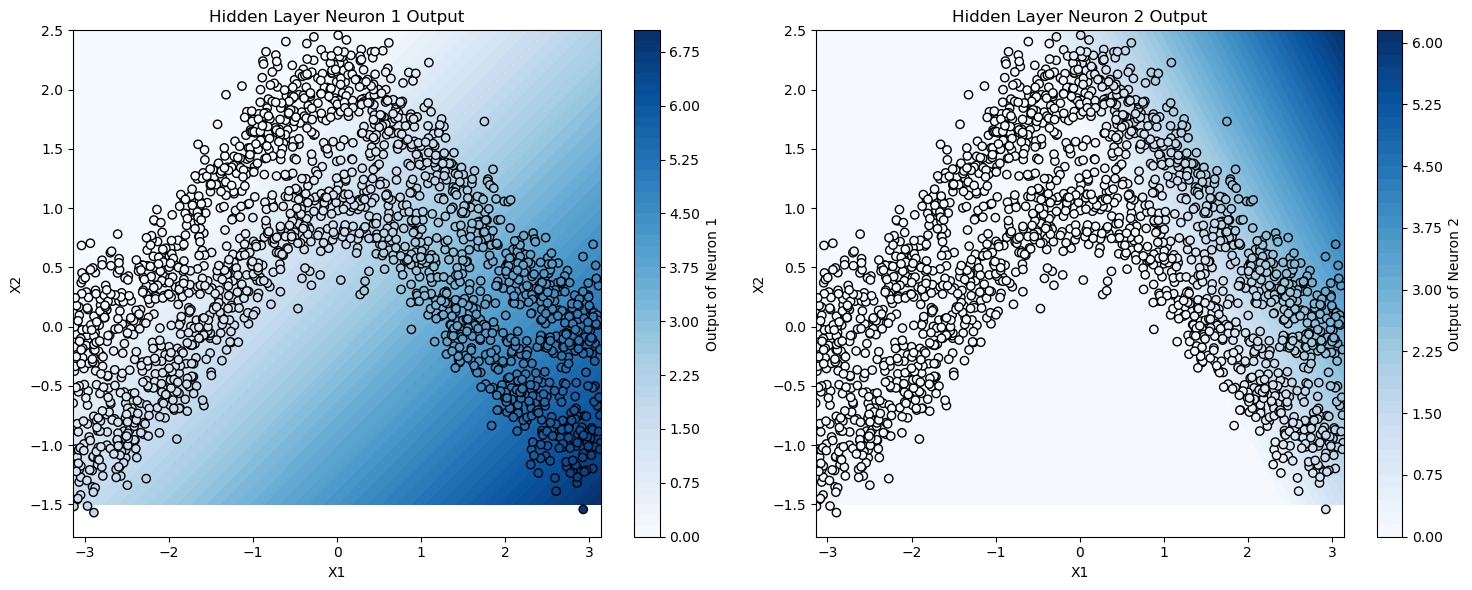

In [22]:
# Draw a heatmap of the output of the hidden layer neurons
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for i in range(2):
    vmin= min(z[:,i].min(), z_grid[:,i].min())   
    vmax= max(z[:,i].max(), z_grid[:,i].max())
    ax[i].contourf(X_grid1, X_grid2, z_grid[:,i].reshape(X_grid1.shape), levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[i].scatter(X[:,0], X[:,1], c=z[:,i], cmap='Blues', edgecolor='k',vmin=vmin, vmax=vmax)
    ax[i].set_xlabel('X1')
    ax[i].set_ylabel('X2')
    ax[i].set_title(f'Hidden Layer Neuron {i+1} Output')
    cbar = plt.colorbar(ax[i].collections[0], ax=ax[i])
    cbar.set_label(f'Output of Neuron {i+1}')
fig.tight_layout() 
plt.show()

We can also print out the values of the weights and bias for each layer:

In [23]:
print('Hidden layer bias:', model_hidden2.layers[1].bias.numpy())
print('Hidden layer weights:', model_hidden2.layers[1].kernel.numpy())
print('Output layer bias:', model_hidden2.layers[2].bias.numpy())
print('Output layer weights:', model_hidden2.layers[2].kernel.numpy())

Hidden layer bias: [ 2.5324523 -2.03087  ]
Hidden layer weights: [[ 0.8623005  1.6305681]
 [-1.2006363  1.2047334]]
Output layer bias: [1.3502616]
Output layer weights: [[-2.5771835]
 [ 6.1531744]]


### Increasing the width of the network

### 🚩 Exercise 5 (CORE)

Now, try increasing the number of hidden units to 5.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and what features appear to be extracted by each hidden unit. Which model would you choose and why?

Training 5-neuron model...
Training complete!


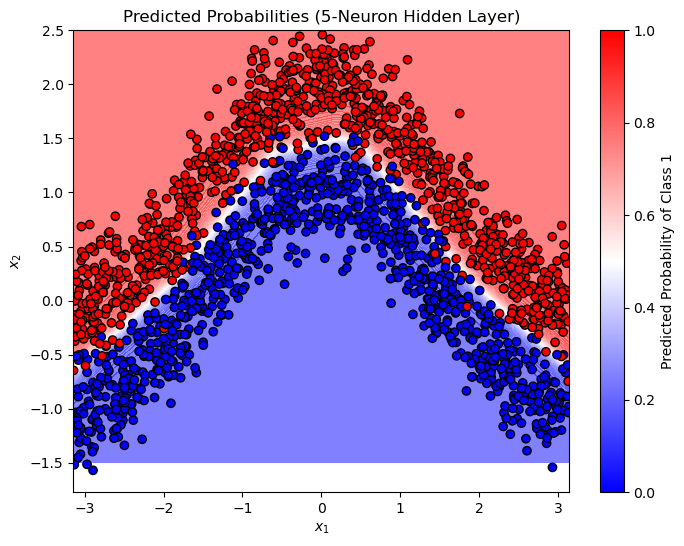

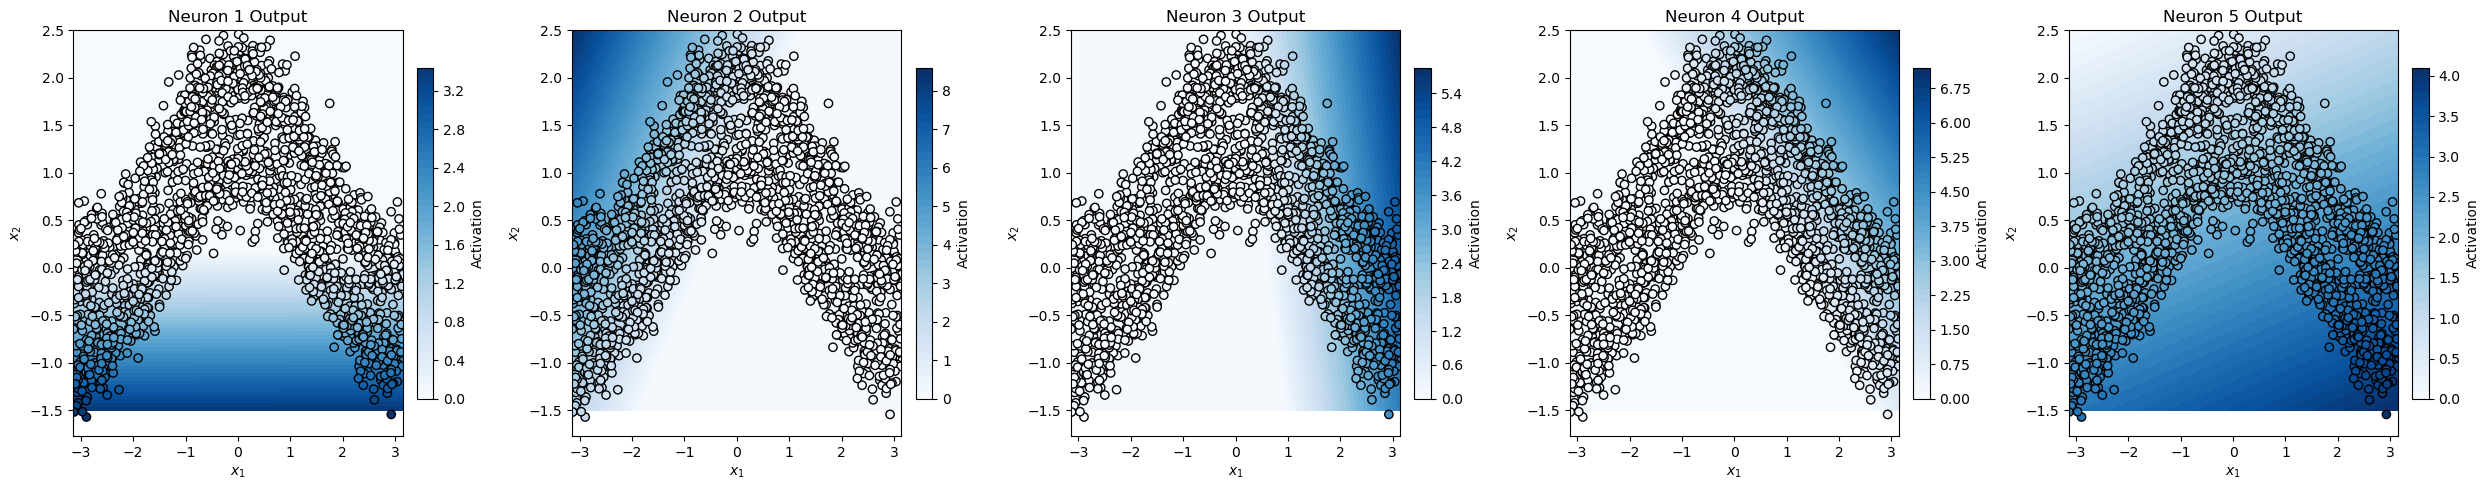

In [24]:
# Code for your answer here!
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

input_layer_5 = keras.Input(shape=(D,))
hidden_layer_5 = keras.layers.Dense(5, activation='relu')(input_layer_5)
output_layer_5 = keras.layers.Dense(1, activation='sigmoid')(hidden_layer_5)

model_hidden5 = keras.Model(inputs=input_layer_5, outputs=output_layer_5)

model_hidden5.compile(
    loss='binary_crossentropy', 
    optimizer='adam',
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

print("Training 5-neuron model...")
history_hidden5 = model_hidden5.fit(
    x=X, y=y, epochs=150, shuffle=True, validation_split=0.1, verbose=0 # verbose=0 hides the spam
)
print("Training complete!")

y_pred_prob_hidden5 = model_hidden5.predict(X_grid, verbose=0)

plt.figure(figsize=(8, 6))
plt.contourf(X_grid1, X_grid2, y_pred_prob_hidden5.reshape(X_grid1.shape), levels=50, cmap='bwr', alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Predicted Probabilities (5-Neuron Hidden Layer)')
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

hidden_layer_model_5 = keras.Model(inputs=model_hidden5.input, outputs=model_hidden5.layers[1].output)

z_grid_5 = hidden_layer_model_5(X_grid).numpy()
z_5 = hidden_layer_model_5(X).numpy()

# Plot the 5 hidden units
fig, ax = plt.subplots(1, 5, figsize=(25, 5))

for i in range(5):
    vmin = min(z_5[:,i].min(), z_grid_5[:,i].min())
    vmax = max(z_5[:,i].max(), z_grid_5[:,i].max())
    
    cf = ax[i].contourf(X_grid1, X_grid2, z_grid_5[:,i].reshape(X_grid1.shape), 
                        levels=50, cmap='Blues', vmin=vmin, vmax=vmax)
    
    ax[i].scatter(X[:,0], X[:,1], c=z_5[:,i], cmap='Blues', edgecolor='k', vmin=vmin, vmax=vmax)
    
    ax[i].set_xlabel('$x_1$')
    ax[i].set_ylabel('$x_2$')
    ax[i].set_title(f'Neuron {i+1} Output')
    
    cbar = plt.colorbar(cf, ax=ax[i], fraction=0.046, pad=0.04)
    cbar.set_label(f'Activation')

fig.tight_layout()
plt.show()

_By increasing the number of hidden units from 2 to 5, the model's overall decision boundary has become much smoother and non-linear. It now very closely approximates the true cosine curve underlying the data. While the 2-neuron model could only create a rigid, V-shaped boundary (using two lines), the 5-neuron model can combine up to five linear segments, giving it the flexibility to "bend" more naturally around the overlapping regions of the two classes.\
Looking at the five individual neuron heatmaps, we can see that each neuron acts as a simple linear classifier, drawing a single straight line across the input space. Because of the ReLU activation, each neuron is "active" (blue) on only one side of its line. Each unit focuses on extracting a specific linear "slice" of the curve. For example, looking at the plots, one neuron captures the upward slope on the left, another captures the peak in the middle, and others capture the downward slopes on the right. The final output layer then aggregates these five distinct linear features to construct the final curved boundary.\
And I would choose the 5-neuron model. The baseline logistic regression model severely underfits the data because it can only draw a single straight line. The 2-neuron model is an improvement but is still too rigid to smoothly capture the underlying cosine wave. The 5-neuron model strikes the right balance: it has enough capacity (trainable parameters) to accurately map the complex, non-linear boundary without being unnecessarily large or complex for this specific dataset._

### Increasing the depth of the network

### 🚩 Exercise 6 (CORE)

Now, consider a model with two layers: 5 hidden units in the first layer and 2 hidden units in the second layer.
- Define and compile the model.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit (in both layers) over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted by the second layer compared to the first. Which model would you choose and why?

In [ ]:
# Code for your answer here!

_Type your answer here_

### Changing the activation function

### 🚩 Exercise 7 (EXTRA)

Next, let's explore changing the activation function. 

- Define and compile with your choice of width and depth (number of layers and number of hidden units within each layer), but consider a different activation function for the hidden layer, namely `tanh`.
- Fit the model and train for as many epochs find are needed.
- Draw a heatmap of the predicted probabilities over the grid of input values.
- Draw heatmaps of the output for each hidden unit over the grid of input values.

Comment on how the predictions have changed and differences in the features extracted when using the `tanh` activation function instead of the `relu` activation.

In [ ]:
# Code for your answer here!

_Type your answer here_ 

# Part 2: MNIST Data

### Loading, exploring, and preparing the data

For the second part, we are going to use the MNIST dataset, partly because you are already familiar with it, and partly because it comes with tensorflow, the most widely used library for neural networks in python.

Let's start by load the MNIST data using `keras.datasets.mnist.load_data()`

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)


Let's display the six images in the training set.

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()
for i in range(6):
    ax[i].imshow(X_train[i], cmap="gray_r")
    ax[i].set_title(f"Label: {y_train[i]}")
    ax[i].axis('off')
fig.tight_layout()
plt.show()

Next, we divide the features by 255 (the maximum value of the pixels), so that all pixel values in the training and testing data are between 0 and 1. 

In the workshop, we will be working only with fully connected feed-forward networks (that don't exploit the spatial structure of the images like convolutional neural networks). As such, we also flatten all images to vectors.

In [ ]:
# Rescale the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape the data 
X_train = X_train.reshape((-1, 28 * 28))
X_test = X_test.reshape((-1, 28 * 28))

Lastly, we use convert the labels using a `LabelEncoder`.

In [ ]:
# Converting the labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### 🚩 Exercise 8 (CORE)

As a baseline model, create a pipeline (called `baseline`) that
- first uses PCA to reduce the dimension to 100
- then uses logistic regression with no penalty

Fit the pipeline to the data. Plot the confusion matrix and print the classification report. How many parameters does the logistic regression model have?

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss

# Code for your answer here

Let's plot some of the images that were both correctly and incorrectly classified, along with the corresponding probabilities. 

Note: if you have called your model something other than `baseline`, please change the name in the code below.

In [ ]:
# indices of misclassified examples
misclas_indices = np.where(y_test != y_test_pred)[0]
# indices of correctly classified examples
clas_indices = np.where(y_test == y_test_pred)[0]

# For the first 5 misclassified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = misclas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

In [ ]:
# For the first 5 correctly classified examples, plot the image and a bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i in range(5):
    idx = clas_indices[i]
    ax[i, 0].imshow(X_test[idx].reshape(28, 28), cmap='gray_r')
    ax[i, 0].set_title(f'True label: {y_test[idx]}, Predicted: {y_test_pred[idx]}')
    ax[i, 0].axis('off')
    
    # Get predicted probabilities for each class
    y_prob = baseline.predict_proba(X_test[idx].reshape(1, -1))[0]
    
    # Bar plot of predicted probabilities
    ax[i, 1].bar(range(10), y_prob)
    ax[i, 1].set_xticks(range(10))
    ax[i, 1].set_xticklabels(label_encoder.classes_)
    ax[i, 1].set_ylim(0, 1)
    ax[i, 1].set_title('Predicted Probabilities')
fig.tight_layout()
plt.show()

It can be concerning when we have high probability/confidence for incorrectly classified images. This is quantified across all data points by the cross entropy loss, which for a single data points computes:

$$ L(y, p) = \sum_{c=1}^C y_c\log(p_c).$$

Notice that if the probability of the true class is close to 1, than the loss is zero, but if it is close to zero that the loss is high. 

We can report the cross entropy loss, averaged across all data points. 

In addition, through histogram showing the distribution of the probability of that $y$ is equal to the true test label, we can gain a more detailed understanding. We see that for the correctly classified images, over 4,000 images are correctly classified with a high probability. On the other hand, there are over 100 images that are misclassified with a high probability. 

In [ ]:
y_test_pred_prob = baseline.predict_proba(X_test)
print('Cross entropy loss:', log_loss(y_test, y_test_pred_prob, labels=label_encoder.classes_))

# Extract probabilility of correct label for each data point
prob_correct = y_test_pred_prob[np.arange(len(y_test)), y_test]

# Plot a histogram of the probabilities across data points, for correct or incorrect classification
fig, ax = plt.subplots(1,2,figsize = (10,5))
sns.histplot(x = prob_correct[clas_indices], bins=50, ax=ax[0])
ax[0].set_title('Correctly classified examples')
ax[0].set_xlabel('Probability of true label')
sns.histplot(x = prob_correct[misclas_indices], bins=50, ax=ax[1])
ax[1].set_xlabel('Probability of true label')
ax[1].set_title('Incorrectly classified examples')
plt.show()

### 🚩 Exercise 9 (CORE)

Next, let's fit a fully-connected feed forwared neural network. Note that we need to one-hot encoding the output labels for use in keras in the multiclass setting.

- Define and compile a model with one hidden layer of 128 neurons and ReLU activation. For the final layer, use a softmax with 10 units to obtain the probabilities for each class. Here use the categorical cross entropy loss. 
- Fit the model and train for 10 epochs with a batch size of 128 and a 10% validation split, and plot the loss and accuracy for the training and validation sets as a function of epochs.
- Plot the confusion matrix and print the classification report on the test data.
- Visualize some the test images, along with their probabilities for both correctly and incorrectly classified images.
- Print the cross entropy loss on the test data, and visualize the distribution of the probability of the true labels for correctly and incorrectly classified test points.

In [ ]:
# First create a one-hot encoding of the labels for use in Keras
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)
# Print the first few rows before and after one-hot encoding
print("Original labels:", y_train[:5])
print("One-hot encoded labels:\n", y_train_cat[:5])

In [ ]:
# Code for your answer here!

### 🚩 Exercise 10 (CORE)

Comment on the following:

a. Do you think you need to train the model for more epochs? 

b. Which model do you prefer: the baseline logisitic regression or the neural network? Consider the trade-off between: the number of parameters and predictive performance.

_Type your answer here_

### 🚩 Exercise 11 (EXTRA)

Let's explore a deeper architecture.

- Build a deeper network with three hidden layers, with $D_1 = 128, D_2 = 64, D_1 = 32$ neurons and ReLU activation, and an output layer with 10 neurons and softmax activation.

- Compile and train the model with the same setting as the shallow model.

- Plot the loss and accuracy for the training and validation sets as a function of epochs. Do you think more epochs are needed?

- Plot the confusion matrix, print the classification report, and cross entropy loss. Visualize some the images, along with their probabilities for both correctly and incorrectly classified images.

- Which model do you prefer? Consider the trade-off between: the number of parameters and predictive performance.

In [ ]:
# Code for your answer here!

_Type your answer here_

# Completing the Worksheet

At this point you have hopefully been able to complete all the CORE exercises and attempted the EXTRA ones. Now 
is a good time to check the reproducibility of this document by restarting the notebook's
kernel and rerunning all cells in order.


Before generating the PDF, please **change 'Student 1' and 'Student 2' at the top of the notebook to include your name(s)**.

Once that is done and you are happy with everything, you can then run the following cell 
to generate your PDF. Once generated, please submit this PDF on Learn page by 16:00 PM on the Friday of the week the workshop was given. 

In [ ]:
!jupyter nbconvert --to pdf mlp_week09.ipynb 